<a href="https://colab.research.google.com/github/barronbrn/SistemPrediksiHujan/blob/main/PSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import re

# Library preprocessing & modeling
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# Konfigurasi
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
df = pd.read_excel('/content/Data_Curah_Hujan.xlsx')
df.head(5)

,Tahun,Bulan,Tanggal,Suhu_jam7,Suhu_jam13,Suhu_jam18,Suhu_rata2,Suhu_rata2_24,Suhu_max,Suhu_min,...,Tekanan_udara,Kelembaban_jam7,Kelembaban_jam13,Kelembaban_jam18,Kelembaban_rata2,Kelembaban_rata2_24,KecepatanAngin_rata2,Arah_terbanyak,Kecepatan_max,Arah_angin
0,2020,8,1,24.1,32.5,28.6,27.3,27.9,33.6,23.3,...,1011.4,80.126834,53.137043,72.262296,71,70,4.875000,TG,12,130
1,2020,8,2,24.0,32.3,28.5,27.2,28.0,32.8,23.3,...,1010.8,84.089058,49.140690,71.523597,72,69,4.083333,T,11,130
2,2020,8,3,23.7,32.7,28.5,27.2,28.6,33.0,23.5,...,1010.9,83.159701,56.079228,76.338265,75,72,5.541667,TG,10,130
3,2020,8,4,26.5,31.8,28.3,28.3,28.2,33.0,24.7,...,1009.1,80.451899,60.520376,69.368028,73,74,3.791667,TG,10,120
4,2020,8,5,25.3,31.2,29.8,27.9,28.5,32.7,24.4,...,1010.1,83.005162,58.873915,71.618485,74,73,3.625000,TG,9,60


In [ ]:
#Informasi Dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Tahun                 515 non-null    int64  
 1   Bulan                 515 non-null    int64  
 2   Tanggal               515 non-null    int64  
 3   Suhu_jam7             515 non-null    float64
 4   Suhu_jam13            515 non-null    float64
 5   Suhu_jam18            515 non-null    float64
 6   Suhu_rata2            515 non-null    float64
 7   Suhu_rata2_24         515 non-null    float64
 8   Suhu_max              515 non-null    float64
 9   Suhu_min              515 non-null    float64
 10  Curah_hujan           515 non-null    object 
 11  Lama_jampenyinaran    515 non-null    float64
 12  Persen_jampenyinaran  515 non-null    float64
 13  Peristiwa_khusus      515 non-null    object 
 14  Tanggal.1             515 non-null    int64  
 15  Tekanan_udara         5

,Tahun,Bulan,Tanggal,Suhu_jam7,Suhu_jam13,Suhu_jam18,Suhu_rata2,Suhu_rata2_24,Suhu_max,Suhu_min,...,Tanggal.1,Tekanan_udara,Kelembaban_jam7,Kelembaban_jam13,Kelembaban_jam18,Kelembaban_rata2,Kelembaban_rata2_24,KecepatanAngin_rata2,Kecepatan_max,Arah_angin
count,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,...,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,2020.708738,7.543689,15.772816,26.733010,32.832233,29.040971,28.848155,28.904466,33.957864,25.575728,...,15.720388,1010.594563,84.710616,58.540698,75.649831,75.922330,75.951456,4.483407,12.211650,168.873786
std,0.454786,3.399979,8.812621,1.083497,1.867594,1.533279,1.009918,1.042203,1.392724,0.916480,...,8.814091,1.517604,5.217676,10.526170,8.779031,6.255409,6.512154,1.221812,3.253232,93.114577
min,2020.000000,1.000000,1.000000,23.400000,25.600000,24.400000,26.000000,25.700000,27.600000,22.600000,...,1.000000,1006.000000,61.691456,35.818862,52.604719,57.000000,63.000000,1.625000,5.000000,0.000000
25%,2020.000000,5.000000,8.000000,26.000000,32.100000,28.400000,28.200000,28.300000,33.200000,25.000000,...,8.000000,1009.500000,81.262542,51.037492,69.129825,71.000000,70.000000,3.583333,10.000000,120.000000
50%,2021.000000,8.000000,16.000000,26.800000,33.200000,29.400000,28.800000,29.000000,34.100000,25.600000,...,16.000000,1010.700000,84.853398,57.661729,75.106784,76.000000,76.000000,4.333333,12.000000,140.000000
75%,2021.000000,10.000000,23.000000,27.400000,34.000000,30.000000,29.500000,29.700000,35.000000,26.200000,...,23.000000,1011.800000,88.566123,63.848986,80.765282,81.000000,81.000000,5.208333,14.000000,180.000000
max,2021.000000,12.000000,31.000000,30.000000,36.200000,32.000000,31.700000,31.400000,37.500000,28.000000,...,31.000000,1014.100000,96.623276,93.548692,96.654290,93.000000,94.000000,8.375000,29.000000,360.000000


In [ ]:
# Cek Missing Value
missing = df.isnull().sum()
print(missing)

Tahun                   0
Bulan                   0
Tanggal                 0
Suhu_jam7               0
Suhu_jam13              0
Suhu_jam18              0
Suhu_rata2              0
Suhu_rata2_24           0
Suhu_max                0
Suhu_min                0
Curah_hujan             0
Lama_jampenyinaran      0
Persen_jampenyinaran    0
Peristiwa_khusus        0
Tanggal.1               0
Tekanan_udara           0
Kelembaban_jam7         0
Kelembaban_jam13        0
Kelembaban_jam18        0
Kelembaban_rata2        0
Kelembaban_rata2_24     0
KecepatanAngin_rata2    0
Arah_terbanyak          0
Kecepatan_max           0
Arah_angin              0
dtype: int64


In [ ]:
#Menghapus Kolom Tanggal yang Duplikat
df = df.drop(columns=['Tanggal.1'])

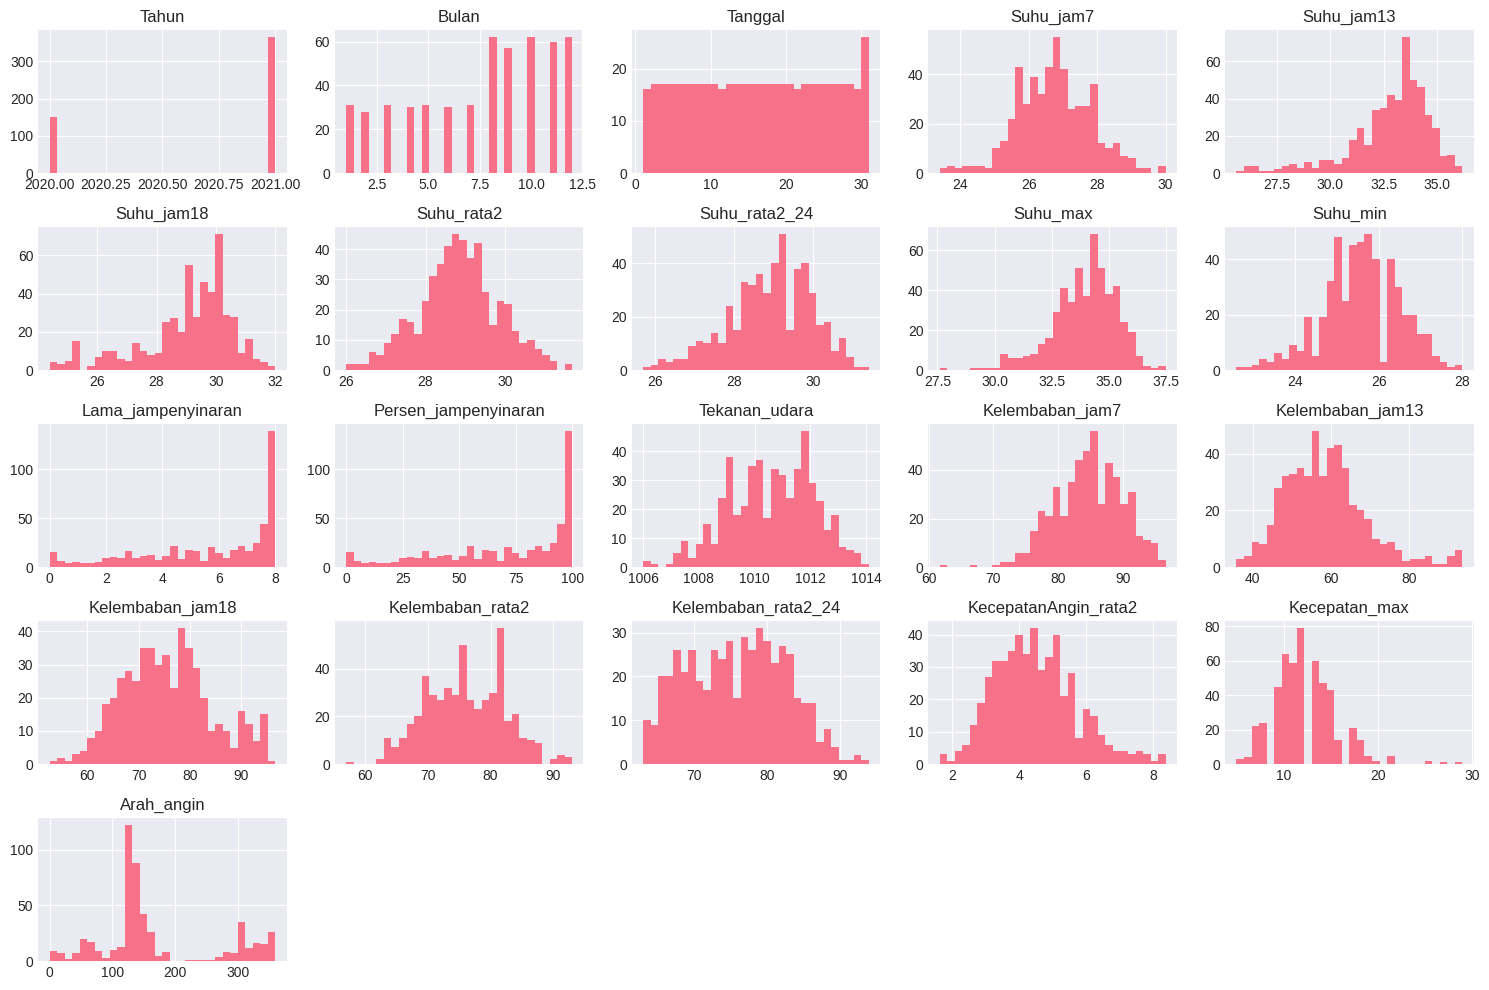

In [ ]:
# Distribusi Variabel Numerik
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

df[numerical_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

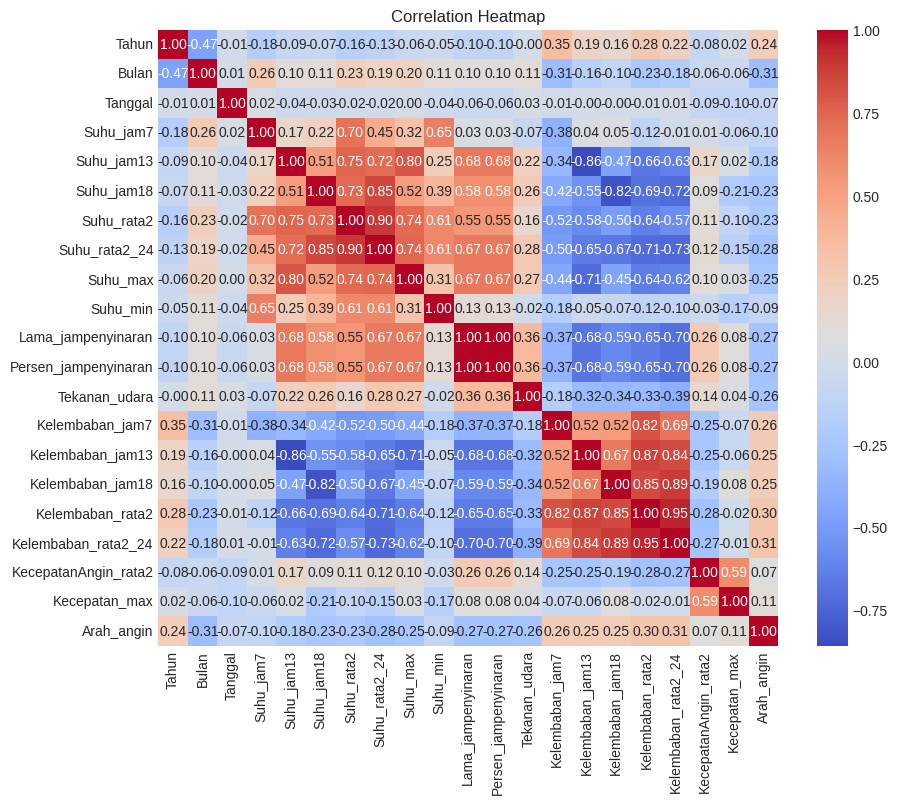

In [ ]:
# Analisis Korelasi Antar Variabel
plt.figure(figsize=(10,8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# ============================================
# BAGIAN 2: PREPROCESSING
# ============================================

# 1. Pastikan Data Terurut Waktu
# Konversi kolom tanggal gabungan
df['Date'] = pd.to_datetime(
    df[['Tahun', 'Bulan', 'Tanggal']].astype(str).agg('-'.join, axis=1),
    format='%Y-%m-%d', errors='coerce'
)
# Urutkan data (Penting untuk cuaca!)
df_processed = df.sort_values('Date').reset_index(drop=True)

# 2. Pembersihan Target (Curah Hujan) yang Lebih Kuat
cleaned_target = []
for val in df_processed['Curah_hujan']:
    # Ubah ke string, kecilkan huruf, hapus spasi
    s = str(val).strip().lower()

    # Cek nilai "kering" atau kosong
    if s in ['-', 'nan', '', ' ', 'none', 'null'] or 'ttu' in s or 'trace' in s:
        cleaned_target.append(0)
    else:
        try:
            # Ganti koma dengan titik (jika format Indonesia: 2,5 -> 2.5)
            s = s.replace(',', '.')

            # Coba ambil angka menggunakan Regex
            found = re.findall(r"[-+]?\d*\.\d+|\d+", s)
            if found:
                num = float(found[0])
                # Anggap hujan jika curah hujan > 0 (bisa disesuaikan misal > 1)
                cleaned_target.append(1 if num > 0 else 0)
            else:
                cleaned_target.append(0)
        except Exception as e:
            # Jika error, print sampelnya biar kita tahu (jangan di-silent!)
            print(f"Gagal memproses nilai: {val} | Error: {e}")
            cleaned_target.append(0)

df_processed['Hujan_Target'] = cleaned_target

# Cek Hasilnya
proporsi = df_processed['Hujan_Target'].mean() * 100
jumlah_hujan = df_processed['Hujan_Target'].sum()
print(f"Hari Hujan: {jumlah_hujan} hari ({proporsi:.2f}%)")

# 3. Feature Engineering (Fitur Waktu)
df_processed['Hujan_Kemarin'] = df_processed['Hujan_Target'].shift(1)
df_processed['Hujan_2HariLalu'] = df_processed['Hujan_Target'].shift(2)
df_processed['Rata2_Hujan_3Hari'] = df_processed['Hujan_Target'].rolling(3).mean().shift(1)

# Fitur Musim
df_processed['Musim'] = df_processed['Bulan'].apply(
    lambda x: 0 if x in [12, 1, 2] else (1 if x in [6, 7, 8] else 2)
)

# 4. Isi Missing Values
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Hapus baris awal yang kosong karena shift/lag
df_processed = df_processed.dropna().reset_index(drop=True)
print(f"Preprocessing Selesai. Shape: {df_processed.shape}")

Hari Hujan: 177 hari (34.37%)
Preprocessing Selesai. Shape: (515, 30)


### Visualisasi Distribusi Kelas 'Hujan_Target' setelah Preprocessing

Rincian Jumlah Data:
- Tidak Hujan (0): 338 hari
- Hujan (1)      : 177 hari


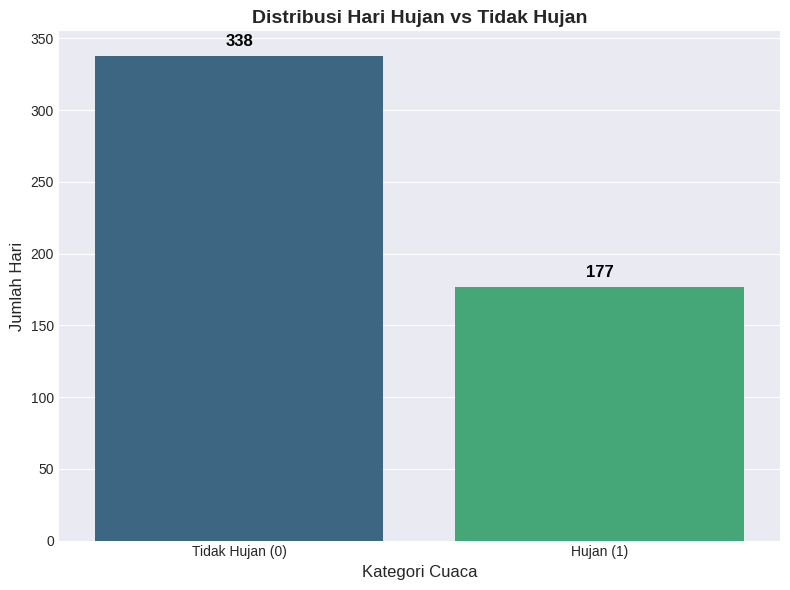

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Hujan_Target', data=df_processed, palette='viridis')

plt.title('Distribusi Hari Hujan vs Tidak Hujan', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Cuaca', fontsize=12)
plt.ylabel('Jumlah Hari', fontsize=12)
plt.xticks([0, 1], ['Tidak Hujan (0)', 'Hujan (1)'])


for p in ax.patches:
    height = p.get_height()

    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, color='black', fontweight='bold',
                xytext=(0, 5),
                textcoords='offset points')


jumlah = df_processed['Hujan_Target'].value_counts()
print("Rincian Jumlah Data:")
print(f"- Tidak Hujan (0): {jumlah[0]} hari")
print(f"- Hujan (1)      : {jumlah[1]} hari")


plt.tight_layout()
plt.show()

In [ ]:
# 4. Feature Engineering: Lag Features
df_processed['Hujan_Kemarin'] = df_processed['Hujan_Target'].shift(1)
df_processed['Hujan_2HariLalu'] = df_processed['Hujan_Target'].shift(2)
df_processed['Rata2_Hujan_3Hari'] = df_processed['Hujan_Target'].rolling(3).mean().shift(1)

# Fitur Musim
# 0: Hujan (Des-Feb), 1: Kemarau (Jun-Agust), 2: Pancaroba
df_processed['Musim'] = df_processed['Bulan'].apply(
    lambda x: 0 if x in [12, 1, 2] else (1 if x in [6, 7, 8] else 2)
)

# 5. Handling Missing Values
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(median_val)

# Hapus baris kosong akibat shift/lag (baris awal)
df_processed = df_processed.dropna().reset_index(drop=True)

print(f"Preprocessing Selesai. Shape akhir: {df_processed.shape}")
print(df_processed[['Date', 'Curah_hujan', 'Hujan_Target', 'Hujan_Kemarin']].head())

Preprocessing Selesai. Shape akhir: (515, 30)
        Date Curah_hujan  Hujan_Target  Hujan_Kemarin
0 2020-08-01           -             0            0.0
1 2020-08-02           -             0            0.0
2 2020-08-03           -             0            0.0
3 2020-08-04         TTU             0            0.0
4 2020-08-05           -             0            0.0


In [ ]:
# ============================================
# BAGIAN 3: FEATURE SELECTION
# ============================================

# Buang kolom yang tidak diperlukan untuk prediksi
drop_cols = ['Curah_hujan', 'Date', 'Peristiwa_khusus', 'Arah_terbanyak', 'Tanggal.1', 'Hujan_Target']
feature_cols = [c for c in df_processed.columns if c not in drop_cols]

X = df_processed[feature_cols]
y = df_processed['Hujan_Target']

# Encode kolom kategorial jika masih ada
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print(f"Fitur yang digunakan ({len(feature_cols)}):")
print(feature_cols)

Fitur yang digunakan (25):
['Tahun', 'Bulan', 'Tanggal', 'Suhu_jam7', 'Suhu_jam13', 'Suhu_jam18', 'Suhu_rata2', 'Suhu_rata2_24', 'Suhu_max', 'Suhu_min', 'Lama_jampenyinaran', 'Persen_jampenyinaran', 'Tekanan_udara', 'Kelembaban_jam7', 'Kelembaban_jam13', 'Kelembaban_jam18', 'Kelembaban_rata2', 'Kelembaban_rata2_24', 'KecepatanAngin_rata2', 'Kecepatan_max', 'Arah_angin', 'Hujan_Kemarin', 'Hujan_2HariLalu', 'Rata2_Hujan_3Hari', 'Musim']


In [ ]:
# ============================================
# BAGIAN 4: SPLITTING DATA (TIME SERIES)
# ============================================

split_point = int(len(X) * 0.8) # 80% data awal

X_train_raw = X.iloc[:split_point]
y_train_raw = y.iloc[:split_point]

X_test = X.iloc[split_point:]
y_test = y.iloc[split_point:]

print(f"Data Training: {X_train_raw.shape[0]} baris")
print(f"Data Testing:  {X_test.shape[0]} baris")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test)

Data Training: 412 baris
Data Testing:  103 baris


Distribusi Kelas Awal:
Hujan_Target
0    279
1    133
Name: count, dtype: int64
Distribusi setelah SMOTE:
Hujan_Target
0    279
1    279
Name: count, dtype: int64


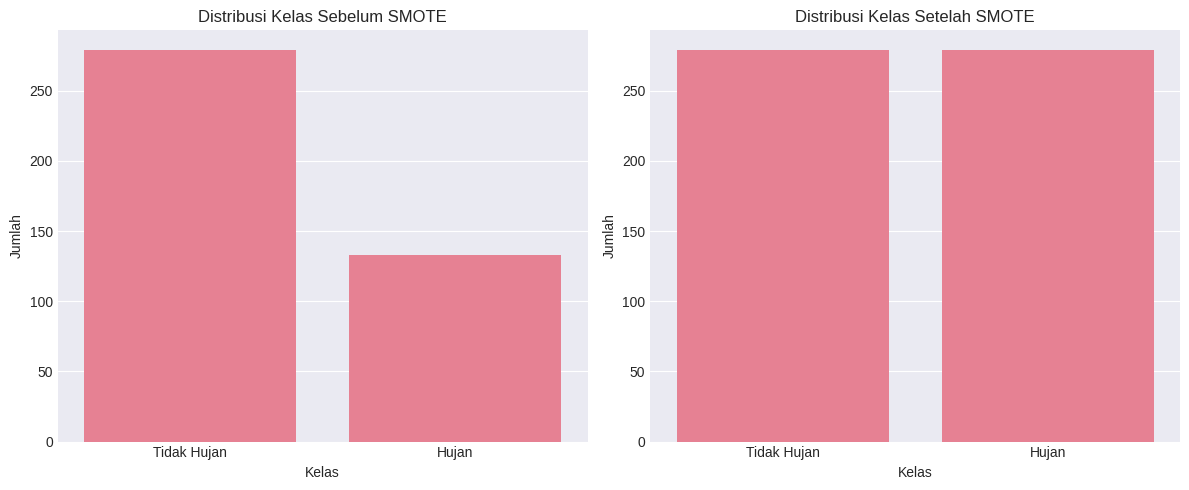

In [ ]:
# ============================================
# BAGIAN 5: HANDLING IMBALANCE (SAFE MODE)
# ============================================

# Cek jumlah kelas di data training
counts = y_train_raw.value_counts()
print(f"Distribusi Kelas Awal:\n{counts}")

# Visualisasi sebelum SMOTE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train_raw)
plt.title('Distribusi Kelas Sebelum SMOTE')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak Hujan', 'Hujan'])

if len(counts) > 1:
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_raw)
    print(f"Distribusi setelah SMOTE:\n{y_train_balanced.value_counts()}")

    # Visualisasi setelah SMOTE
    plt.subplot(1, 2, 2)
    sns.countplot(x=y_train_balanced)
    plt.title('Distribusi Kelas Setelah SMOTE')
    plt.xlabel('Kelas')
    plt.ylabel('Jumlah')
    plt.xticks([0, 1], ['Tidak Hujan', 'Hujan'])
    plt.tight_layout()
    plt.show()
else:
    X_train_balanced = X_train_scaled
    y_train_balanced = y_train_raw
    plt.title('Tidak ada Imbalance untuk diatasi')
    plt.show()


In [ ]:
# ============================================
# BAGIAN 6: TRAINING & EVALUASI
# ============================================


# Definisi Model
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = []
trained_models = {}

print(f"{'Model':<20} | {'Acc':<8} | {'F1-Score':<8} | {'AUC':<8}")
print("-" * 55)

# Loop training tanpa fungsi def
for name, model in models.items():
    # 1. Training (pakai data balanced dari Section 5)
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model

    # 2. Prediksi ke Data Test (pakai data scaled dari Section 4)
    y_pred = model.predict(X_test_scaled)

    # Cek probabilitas untuk AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = [0] * len(y_test)

    # 3. Hitung Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = 0

    # 4. Simpan hasil
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})
    print(f"{name:<20} | {acc:.4f}   | {f1:.4f}     | {auc:.4f}")

# Simpan ke DataFrame
results_df = pd.DataFrame(results)

Model                | Acc      | F1-Score | AUC     
-------------------------------------------------------
Logistic Regression  | 0.7282   | 0.6216     | 0.8494
Random Forest        | 0.7864   | 0.7381     | 0.8394
XGBoost              | 0.6990   | 0.6517     | 0.8024
SVM                  | 0.7961   | 0.7342     | 0.8729



HASIL EVALUASI KLASIFIKASI: RANDOM FOREST
              precision    recall  f1-score   support

 Tidak Hujan       0.79      0.85      0.82        59
       Hujan       0.78      0.70      0.74        44

    accuracy                           0.79       103
   macro avg       0.78      0.78      0.78       103
weighted avg       0.79      0.79      0.78       103

--------------------------------------------------
F1-Score (Macro) : 0.7381
ROC-AUC Score    : 0.8394


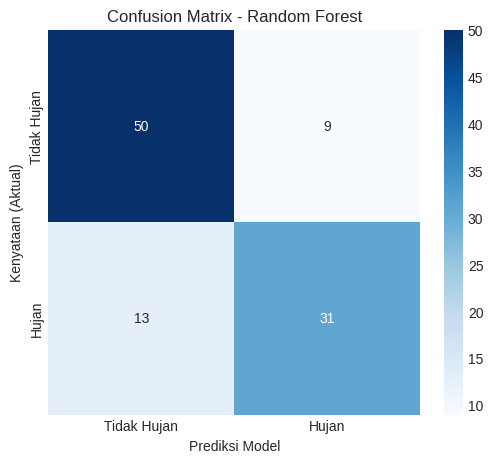

In [ ]:
# ============================================
# BAGIAN 7: EVALUASI DETAIL & VISUALISASI
# ============================================
from sklearn.metrics import classification_report, confusion_matrix

# Cari Model Terbaik
best_row = results_df.sort_values(by='F1', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_model = trained_models[best_model_name]

# Lakukan prediksi ulang menggunakan model terbaik pada data test
y_pred_best = best_model.predict(X_test_scaled)

# Cek probabilitas untuk ROC-AUC
if hasattr(best_model, 'predict_proba'):
    y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
    roc_score = roc_auc_score(y_test, y_prob_best)
else:
    roc_score = 0

print("\n" + "="*50)
print(f"HASIL EVALUASI KLASIFIKASI: {best_model_name.upper()}")
print("="*50)

# Menampilkan Precision, Recall, F1-Score per kelas
print(classification_report(y_test, y_pred_best,
                            target_names=['Tidak Hujan', 'Hujan']))

print("-" * 50)
print(f"F1-Score (Macro) : {best_row['F1']:.4f}")
print(f"ROC-AUC Score    : {roc_score:.4f}")
print("="*50)


# 2. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Hujan', 'Hujan'],
            yticklabels=['Tidak Hujan', 'Hujan'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Kenyataan (Aktual)')
plt.xlabel('Prediksi Model')
plt.show()



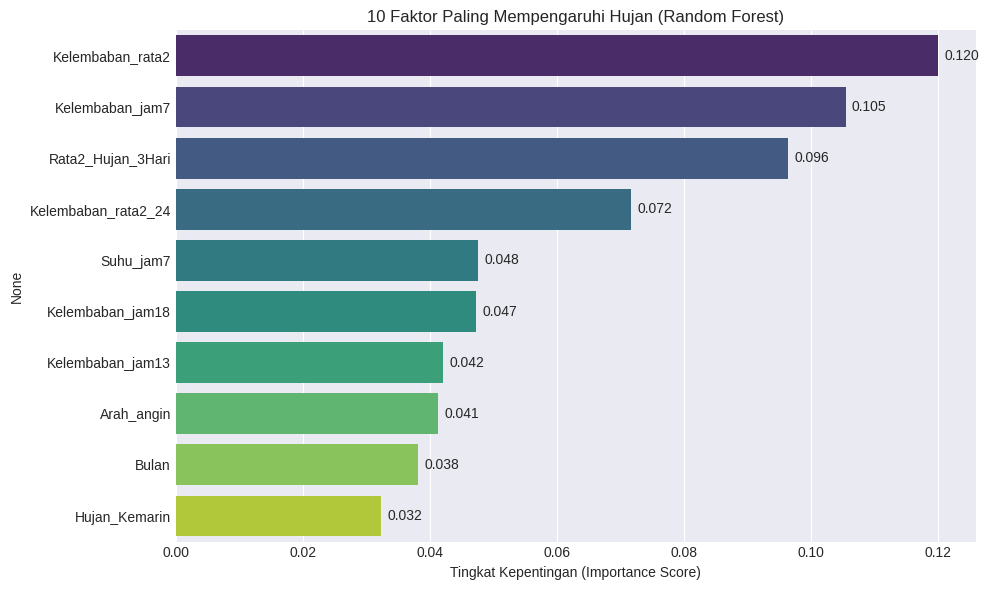

In [ ]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    # Ambil nama fitur
    feat_names = X.columns

    # Urutkan berdasarkan tingkat kepentingan
    feat_imp = pd.Series(best_model.feature_importances_, index=feat_names).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')

    for i, v in enumerate(feat_imp.values):
        plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

    plt.title(f'10 Faktor Paling Mempengaruhi Hujan ({best_model_name})')
    plt.xlabel('Tingkat Kepentingan (Importance Score)')
    plt.tight_layout()
    plt.show()
else:
    print("Model ini tidak mendukung visualisasi Feature Importance standar.")

Model dah beres gaes
tinggal bikin laporannya

In [ ]:


# 1. Siapkan data
df_export = X.copy()
df_export['Hujan_Target'] = y  # Pastikan target masuk

# 2. TAMBAHAN PENTING: Buat Kolom 'Date' dari Tahun, Bulan, Tanggal
# Pandas butuh nama kolom bahasa inggris (year, month, day) untuk konversi otomatis
df_export['Date'] = pd.to_datetime(df_export[['Tahun', 'Bulan', 'Tanggal']].rename(columns={
    'Tahun': 'year',
    'Bulan': 'month',
    'Tanggal': 'day'
}))

# 3. Bungkus dan Simpan
model_data = {
    'model': best_model,
    'scaler': scaler,
    'features': X.columns.tolist(),
    'df_history': df_export  # Sekarang df_export sudah punya kolom 'Date'
}

import joblib
joblib.dump(model_data, 'model_hujan.pkl')
print("Model tersimpan. Kolom:", df_export.columns.tolist())

Model tersimpan. Kolom: ['Tahun', 'Bulan', 'Tanggal', 'Suhu_jam7', 'Suhu_jam13', 'Suhu_jam18', 'Suhu_rata2', 'Suhu_rata2_24', 'Suhu_max', 'Suhu_min', 'Lama_jampenyinaran', 'Persen_jampenyinaran', 'Tekanan_udara', 'Kelembaban_jam7', 'Kelembaban_jam13', 'Kelembaban_jam18', 'Kelembaban_rata2', 'Kelembaban_rata2_24', 'KecepatanAngin_rata2', 'Kecepatan_max', 'Arah_angin', 'Hujan_Kemarin', 'Hujan_2HariLalu', 'Rata2_Hujan_3Hari', 'Musim', 'Hujan_Target', 'Date']
